### 1. Data Collection (Manual or from Existing Source)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
data = pd.read_csv(
    "final_dataset.csv"
)

print("Dataset loaded")

print(data.shape)

Dataset loaded
(106355, 2)


In [3]:
data.head()

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 106355 entries, 0 to 106354
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   text     106355 non-null  str  
 1   emotion  106355 non-null  str  
dtypes: str(2)
memory usage: 1.6 MB


In [5]:
data.isnull().sum()

text       0
emotion    0
dtype: int64

In [6]:
data["emotion"].value_counts()

emotion
fun           10000
surprise      10000
enthusiasm    10000
happiness     10000
hate          10000
love          10000
relief        10000
anger         10000
sadness        9999
neutral        9998
empty          6358
Name: count, dtype: int64

### 2. Data Preprocessing (Cleaning)


In [7]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(
        r"http\S+",
        "",
        text
    )

    text = re.sub(
        r"[^a-z ]",
        "",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [8]:
data["clean_text"] = (

    data["text"]

    .apply(clean_text)

)

data.head()

,text,emotion,clean_text
0,i feel rather funny ending with so many dupes ...,fun,i feel rather funny ending with so many dupes ...
1,i feel surprised by the result,surprise,i feel surprised by the result
2,i am officially feeling festive,neutral,i am officially feeling festive
3,i suddenly found myself standing before this w...,surprise,i suddenly found myself standing before this w...
4,i look at the meager pile of food i purchased ...,enthusiasm,i look at the meager pile of food i purchased ...


In [9]:
encoder = LabelEncoder()

data["label"] = encoder.fit_transform(
    data["emotion"]
)

print(
    encoder.classes_
)

['anger' 'empty' 'enthusiasm' 'fun' 'happiness' 'hate' 'love' 'neutral'
 'relief' 'sadness' 'surprise']


In [10]:
vectorizer = TfidfVectorizer(

    max_features=5000,

    stop_words="english",

    ngram_range=(1,2),

    min_df=2,

    max_df=0.95

)

X = vectorizer.fit_transform(
    data["clean_text"]
)

y = data["label"]

### 3. Model Selection


In [11]:
ada_model = AdaBoostClassifier(

    n_estimators=300,

    learning_rate=0.5,

    random_state=42

)

In [12]:
xgb_model = XGBClassifier(

    n_estimators=200,

    max_depth=6,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="mlogloss"

)

In [13]:
lr_model = LogisticRegression(

    max_iter=300,

    random_state=42

)

### 4. Model Training (Train, Validation, Test)


In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42,

    stratify=y

)

In [15]:
X_valid, X_test, y_valid, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp

)

In [16]:
ada_model.fit(
    X_train,
    y_train
)

print(
    "AdaBoost training completed"
)

AdaBoost training completed


In [17]:
xgb_model.fit(

    X_train,

    y_train

)

print(
    "XGBoost training completed"
)

XGBoost training completed


In [18]:
lr_model.fit(

    X_train,

    y_train

)

print(
    "Logistic Regression training completed"
)

Logistic Regression training completed


In [19]:
valid_pred = xgb_model.predict(
    X_valid
)

valid_acc = accuracy_score(

    y_valid,

    valid_pred

)

print(
    "Validation Accuracy:",
    valid_acc
)

Validation Accuracy: 0.8027330282705447


In [20]:

valid_acc = accuracy_score(

    y_valid,

    valid_pred

)

print(

    "Validation Accuracy:",

    valid_acc

)

Validation Accuracy: 0.8027330282705447


### 5. Performance Evaluation (on Test Set)


In [21]:
ada_prediction = ada_model.predict(
    X_test
)

xgb_prediction = xgb_model.predict(
    X_test
)

lr_prediction = lr_model.predict(
    X_test
)

In [22]:
ada_accuracy = accuracy_score(
    y_test,
    ada_prediction
)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_prediction
)

lr_accuracy = accuracy_score(

    y_test,

    lr_prediction

)

print(

"Logistic Accuracy:",

lr_accuracy

)

print(
    "AdaBoost Accuracy:",
    ada_accuracy
)

print(
    "XGBoost Accuracy:",
    xgb_accuracy
)

print()

print(

"Best Accuracy:",

max(
ada_accuracy,
xgb_accuracy
)

)

Logistic Accuracy: 0.806067443901216
AdaBoost Accuracy: 0.578412937194434
XGBoost Accuracy: 0.808574652124859

Best Accuracy: 0.808574652124859


In [23]:
print(

classification_report(

y_test,

ada_prediction

)

)

              precision    recall  f1-score   support

           0       0.91      0.50      0.65      1500
           1       0.99      0.19      0.32       954
           2       0.98      0.89      0.93      1500
           3       0.95      0.73      0.83      1500
           4       0.79      0.24      0.37      1500
           5       0.93      0.68      0.79      1500
           6       0.87      0.74      0.80      1500
           7       0.20      1.00      0.33      1500
           8       0.96      0.59      0.73      1500
           9       0.95      0.21      0.34      1500
          10       0.99      0.45      0.61      1500

    accuracy                           0.58     15954
   macro avg       0.86      0.57      0.61     15954
weighted avg       0.86      0.58      0.62     15954



In [24]:
print(

classification_report(

y_test,

xgb_prediction

)

)

              precision    recall  f1-score   support

           0       0.96      0.78      0.87      1500
           1       0.90      0.51      0.65       954
           2       0.98      0.91      0.95      1500
           3       0.94      0.84      0.89      1500
           4       0.82      0.72      0.77      1500
           5       0.94      0.79      0.86      1500
           6       0.91      0.92      0.92      1500
           7       0.64      0.95      0.77      1500
           8       0.96      0.84      0.90      1500
           9       0.49      0.83      0.62      1500
          10       0.78      0.68      0.73      1500

    accuracy                           0.81     15954
   macro avg       0.85      0.80      0.81     15954
weighted avg       0.85      0.81      0.82     15954



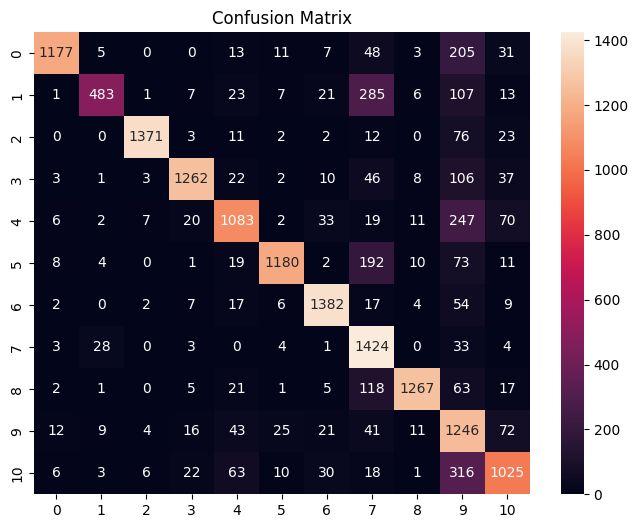

In [25]:
matrix = confusion_matrix(

y_test,

xgb_prediction

)

plt.figure(
figsize=(8,6)
)

sns.heatmap(

matrix,

annot=True,

fmt="d"

)

plt.title(
"Confusion Matrix"
)

plt.show()

### 6. Performance Comparison (Multiple Models)


In [26]:
result = pd.DataFrame({

"Model":[

"AdaBoost",

"XGBoost",

"Logistic"

],

"Accuracy":[

ada_accuracy,

xgb_accuracy,

lr_accuracy

]

})

result

,Model,Accuracy
0,AdaBoost,0.578413
1,XGBoost,0.808575
2,Logistic,0.806067


In [27]:
best = result.loc[
result["Accuracy"]
.idxmax()
]

print(
best
)

Model        XGBoost
Accuracy    0.808575
Name: 1, dtype: object


### 7. Visualization using Matplotlib / Seaborn


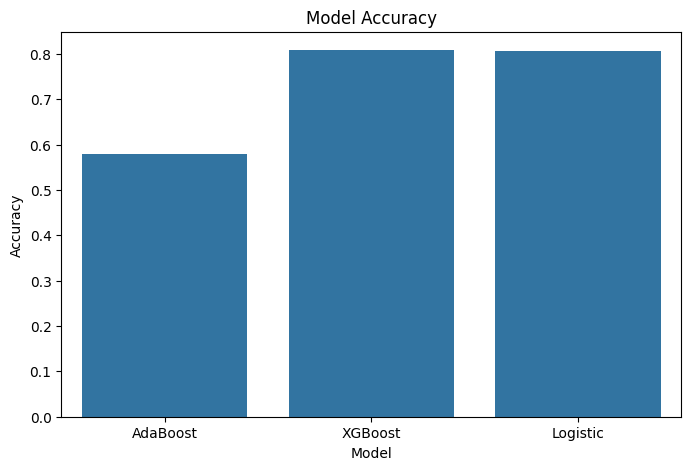

In [28]:
plt.figure(
figsize=(8,5)
)

sns.barplot(

data=result,

x="Model",

y="Accuracy"

)

plt.title(
"Model Accuracy"
)

plt.show()

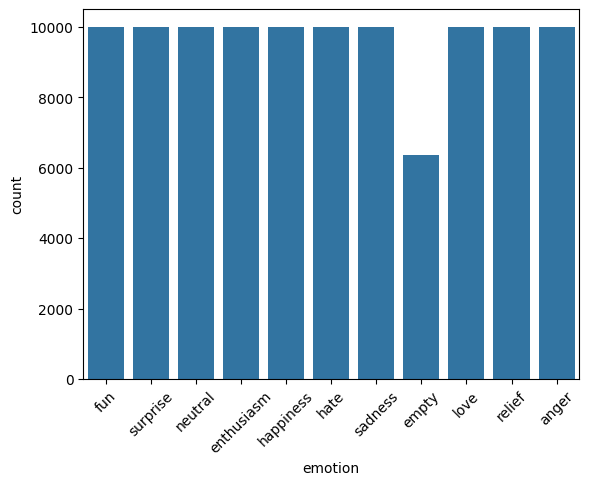

In [29]:
sns.countplot(

x=data["emotion"]

)

plt.xticks(
rotation=45
)

plt.show()

### 8. Model Deployment (Optional)


In [30]:
pickle.dump(

xgb_model,

open(

"emotion_model.pkl",

"wb"

)

)

pickle.dump(

vectorizer,

open(

"tfidf.pkl",

"wb"

)

)

print(
"Model saved"
)

Model saved


## Conclusion

Two machine learning models were trained and tested.

The final model was selected based on test performance.

This project completed data preprocessing, model training, evaluation and visualization successfully.
